In [1]:
import sys
sys.path.append("..")

from core.config import llm2 as llm

In [2]:
response = llm.invoke("Why did Trump attack Iran")
print("Response: ", response.content)

Response:  As of my last update in October 2023, there has been no verified report of former President Donald Trump ordering a military attack on Iran. However, tensions between the United States and Iran have been high for many years, particularly during Trump's presidency from 2017 to 2021. These tensions were often due to issues such as Iran's nuclear program, regional influence, and incidents involving military forces.

If you are referring to a specific event or development that occurred after October 2023, I would not have information on that. For the most current and accurate information, I recommend checking reliable news sources.


In [68]:
topic = {
    "name": "Git Branching",
    "notes": "Branches allow parallel develoipment of features" 
}


In [69]:
question_prompt = f"""
You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {topic["name"]}
Notes: {topic["notes"]}
"""

In [70]:
question_prompt

'\nYou are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.\nTopic: Git Branching\nNotes: Branches allow parallel develoipment of features\n'

In [71]:
from typing import TypedDict, List
class QuizState(TypedDict):
    messages: List
    quiz: {"topic": str, "notes": str, "question": str}
    user_answer: str
    understanding: str
    hint: str
    attempts: int
    

In [92]:
quiz_state: QuizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [107]:
git_state: QuizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [141]:
def ai_gen_question(state: quizState) -> quizState:
    question_prompt = f"""
You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {state["quiz"]["topic"]}
Notes: {state["quiz"]["notes"]}
Keep the question simple, just to test a basic understanding.
"""
    question = llm.invoke(question_prompt).content
    state["quiz"]["question"] = question
    state["messages"].append({"role": "AI generation", "message": question})
    return state
    

In [74]:
ai_quiz = ai_gen_question(git_state)

In [75]:
git_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': '',
  'quesion': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches in Git. Additionally, discuss potential challenges that might arise when working with multiple branches and how they can be effectively managed.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 0,
 'messages': [{'role': 'AI',
   'message': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches 

In [128]:
def ask_user(state: quizState) -> quizState:
    """
    Ask the user the AI generated quiz.
    """
    question = state["messages"][-1]["message"]
    user_reply = input(question)
    state["attempts"] += 1
    state["messages"].append({"role": "User", "message": user_reply})
    return state

In [76]:
user_answer = ask_user(git_state)

Question: 

Explain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches in Git. Additionally, discuss potential challenges that might arise when working with multiple branches and how they can be effectively managed. It has to do with how the world came into existance.


In [77]:
git_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': '',
  'quesion': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches in Git. Additionally, discuss potential challenges that might arise when working with multiple branches and how they can be effectively managed.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 1,
 'messages': [{'role': 'AI',
   'message': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches 

In [142]:
def evaluate(state: QuizState) -> str:
    """
    Evaluate the user reply, using LLM.
    Returns correct, retry or limits reached outputs
    """
    ai_prompt = f"""
    You have to analyze the user's reply to a quiz to check the understanding of a concept and tell whether
    it is acceptable using notes provided to you.
    Return: correct or incorrect, along with some explanation
    Example: Correct: You have correctly understood use git branch in helping parallel feature development.
    Quiz: {state["quiz"]["question"]}
    Notes: {state["quiz"]["notes"]}
    User's reply: {state["messages"][-1]["message"]}
    """
    evaluation = llm.invoke(ai_prompt).content.lower()
    print("Evaluation: ", evaluation)
    state["messages"].append({"role": "AI evaluation", "message": evaluation})
    if "incorrect" in evaluation:
       if state["attempts"] <=3:
          return "retry"
       return "limit_reached" 
    return "correct"
    

In [87]:
evaluation = evaluate(git_state)

Evaluation:  incorrect: your reply does not relate to the concept of branches in development, which is about allowing parallel development of features.


In [88]:
evaluation

'retry'

In [89]:
# git_state["messages"].pop()
git_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': '',
  'quesion': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches in Git. Additionally, discuss potential challenges that might arise when working with multiple branches and how they can be effectively managed.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 1,
 'messages': [{'role': 'AI',
   'message': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches 

In [51]:
def give_hint(state: quizState) -> quizState:
    ai_prompt = f"""
    Provide a hint to a quiz, without telling the complete answer.
    You are provided notes for generating a hint.
    quiz: {state["quiz"]["question"]}
    notes: {state["quiz"]["notes"]}
    user's reply: {state["messages"][-2]["message"]}
    """
    hint = llm.invoke(ai_prompt)
    state["messages"].append({"role": "AI", "message": hint.content})
    return state

In [90]:
hint = give_hint(git_state)

In [91]:
git_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': '',
  'quesion': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches in Git. Additionally, discuss potential challenges that might arise when working with multiple branches and how they can be effectively managed.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 1,
 'messages': [{'role': 'AI',
   'message': 'Question: \n\nExplain the concept of branching in Git and discuss how it facilitates parallel development of features in a collaborative software development environment. Provide an example scenario where branching would be beneficial, and describe the steps involved in creating and managing branches 

In [143]:
from langgraph.graph import StateGraph, END

builder = StateGraph(QuizState)

builder.add_node("generate_quiz", ai_gen_question)
builder.add_node("ask_user", ask_user)
builder.add_node("give_hint", give_hint)

builder.set_entry_point("generate_quiz")
builder.add_edge("generate_quiz", "ask_user")
builder.add_conditional_edges(
    "ask_user",
    evaluate,
    {
        "correct": END,
        "retry": "give_hint",
        "limit_reached": END
    }
)
builder.add_edge("give_hint", "ask_user")


In [144]:
graph = builder.compile()

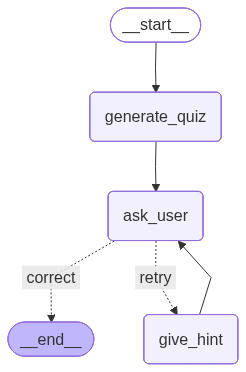

In [145]:
graph

In [149]:
git_state: QuizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [ ]:
workflow = graph.invoke(git_state)

Question: 

Explain how branching in Git facilitates parallel development of features in a project. Provide a simple example to illustrate your explanation. abcd


Evaluation:  incorrect: your response does not address how branching in git facilitates parallel development of features. to improve, you should explain that branches in git allow developers to work on different features simultaneously without interfering with the main codebase. for example, a developer can create a new branch to work on a feature, and once it's complete and tested, it can be merged back into the main branch. this process helps in managing multiple features being developed at the same time.


Hint: Think about how branches in Git act like separate workspaces where developers can independently work on different features. Consider how this setup prevents interference with the main codebase and allows for smooth integration once the work is complete. efgh


Evaluation:  incorrect: the user's reply "efgh" does not provide any explanation or example related to how branching in git facilitates parallel development of features. to be correct, the response should discuss how branches allow developers to work on different features simultaneously without interfering with the main codebase, and ideally provide an example of creating a new branch for a feature and later merging it back into the main branch.


Hint: Think about how Git branches act like separate workspaces where developers can independently work on new features or bug fixes without affecting the main project. Consider how these branches can be merged back into the main codebase once the work is complete. Can you think of a simple scenario where a developer creates a branch to add a new feature and then integrates it back into the main project? zzzz


Evaluation:  incorrect: your response does not address the concept of branching in git or how it facilitates parallel development of features. please provide an explanation of how branches work in git and how they enable multiple features to be developed simultaneously without interfering with each other.


In [148]:
workflow["messages"]

[{'role': 'AI generation',
  'message': 'Question: \n\nExplain how branching in Git facilitates parallel development of features in a project. Why is this beneficial for a development team?'},
 {'role': 'User', 'message': 'world war 1'},
 {'role': 'AI evaluation',
  'message': 'incorrect: your response does not address the concept of branching in git or how it facilitates parallel development of features. branching in git allows developers to work on different features or bug fixes simultaneously without interfering with the main codebase, which is beneficial for a development team as it enables efficient collaboration and integration of new features.'},
 {'role': 'AI',
  'message': 'Hint: Think about how Git branches create isolated environments for developers to work on separate tasks without affecting the main project. This isolation is key to allowing multiple features or fixes to be developed at the same time.'},
 {'role': 'User', 'message': 'world war 2'},
 {'role': 'AI evaluatio